In [1]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'bank+marketing.zip', 'bank-additional', 'bank-additional-extracted', 'bank-additional.zip', 'bank-full.csv', 'bank-names.txt', 'bank.csv', 'bank.zip', 'Mall_Customers.csv.ipynb', 'Untitled.ipynb', '__MACOSX']


In [2]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'bank+marketing.zip', 'bank-additional', 'bank-additional-extracted', 'bank-additional.zip', 'bank-full.csv', 'bank-names.txt', 'bank.csv', 'bank.zip', 'Mall_Customers.csv.ipynb', 'Untitled.ipynb', '__MACOSX']


In [3]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'bank+marketing.zip', 'bank-additional', 'bank-additional-extracted', 'bank-additional.zip', 'bank-full.csv', 'bank-names.txt', 'bank.csv', 'bank.zip', 'Mall_Customers.csv.ipynb', 'Untitled.ipynb', '__MACOSX']


In [4]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'bank+marketing.zip', 'bank-additional', 'bank-additional-extracted', 'bank-additional.zip', 'bank-full.csv', 'bank-names.txt', 'bank.csv', 'bank.zip', 'Mall_Customers.csv.ipynb', 'Task 2', 'Untitled.ipynb', '__MACOSX']


In [5]:
print(os.listdir("Task 2"))

['archive.zip', 'Mall_Customers.csv']


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")

print("Imports done")

Imports done


In [8]:
df = pd.read_csv("Task 2/Mall_Customers.csv")
print(df.shape)
df.head()

(200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [9]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


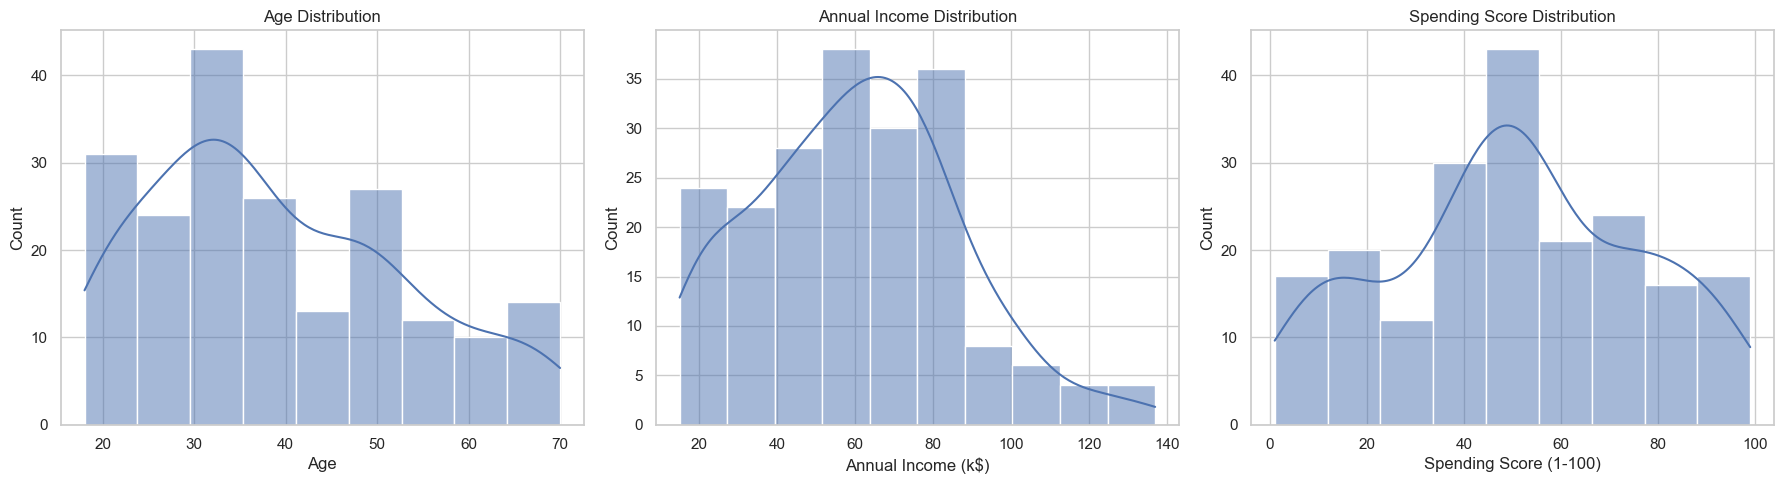

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.histplot(df['Age'], kde=True, ax=axes[0])
axes[0].set_title("Age Distribution")

sns.histplot(df['Annual Income (k$)'], kde=True, ax=axes[1])
axes[1].set_title("Annual Income Distribution")

sns.histplot(df['Spending Score (1-100)'], kde=True, ax=axes[2])
axes[2].set_title("Spending Score Distribution")

plt.tight_layout()
plt.show()

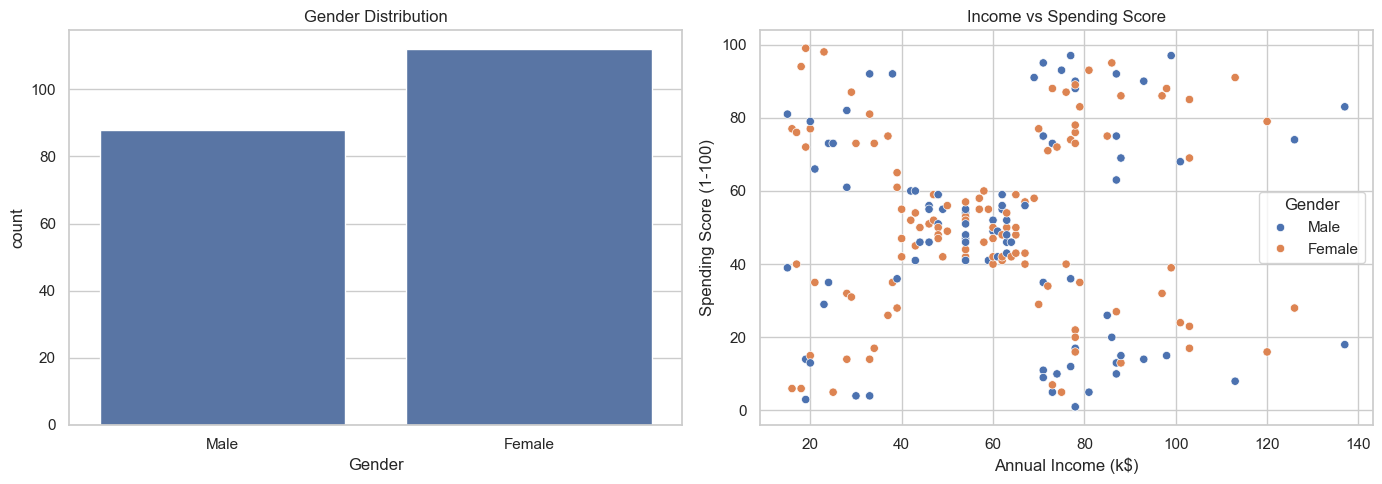

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.countplot(x='Gender', data=df, ax=axes[0])
axes[0].set_title("Gender Distribution")

sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Gender', data=df, ax=axes[1])
axes[1].set_title("Income vs Spending Score")

plt.tight_layout()
plt.show()

In [14]:
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaling done")

Scaling done


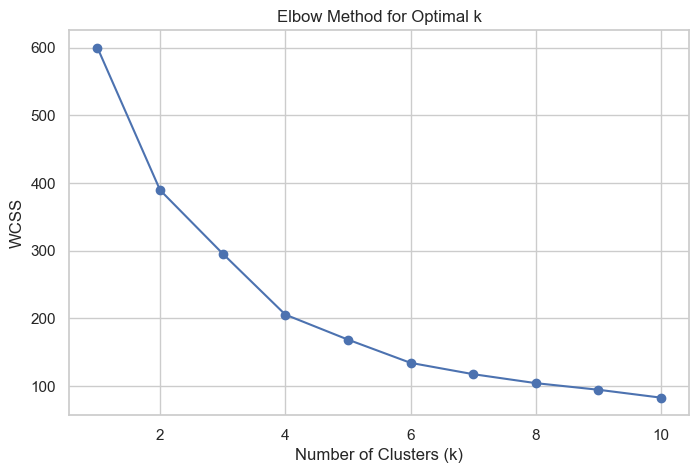

In [15]:
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=3)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, wcss, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal k")
plt.show()

k=2, Silhouette Score=0.3355
k=3, Silhouette Score=0.3579
k=4, Silhouette Score=0.4040
k=5, Silhouette Score=0.4166
k=6, Silhouette Score=0.4284
k=7, Silhouette Score=0.4181
k=8, Silhouette Score=0.4082
k=9, Silhouette Score=0.4153
k=10, Silhouette Score=0.4066


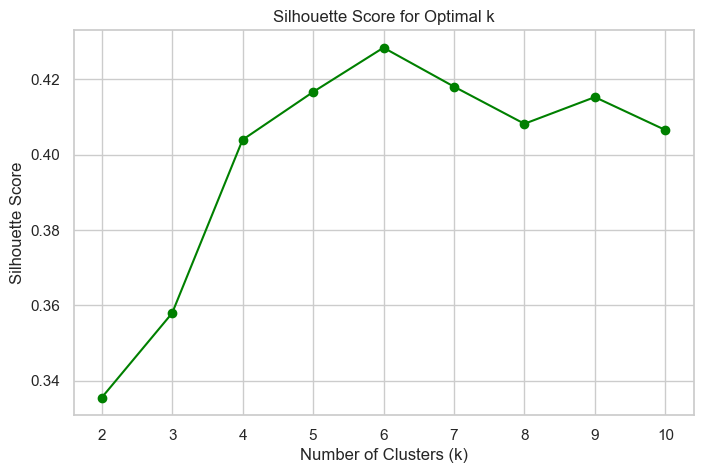

In [16]:
sil_scores = []
K_range_sil = range(2, 11)

for k in K_range_sil:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=3)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    print(f"k={k}, Silhouette Score={score:.4f}")

plt.figure(figsize=(8,5))
plt.plot(list(K_range_sil), sil_scores, marker='o', color='green')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Optimal k")
plt.show()

In [17]:
optimal_k = 5

kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


In [18]:
cluster_summary = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
cluster_summary['Count'] = df['Cluster'].value_counts().sort_index()
cluster_summary

,Age,Annual Income (k$),Spending Score (1-100),Count
Cluster,,,,
0,46.250000,26.750000,18.350000,20
1,25.185185,41.092593,62.240741,54
2,32.875000,86.100000,81.525000,40
3,39.871795,86.102564,19.358974,39
4,55.638298,54.382979,48.851064,47


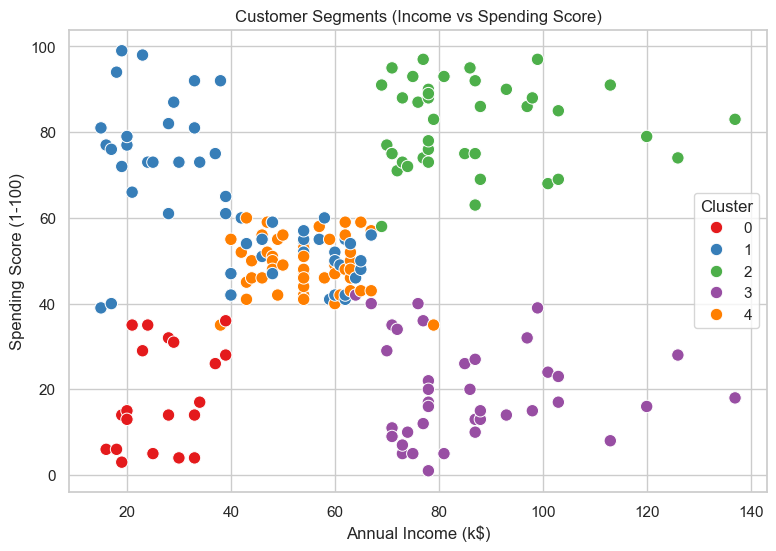

In [19]:
plt.figure(figsize=(9,6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', 
                 hue='Cluster', data=df, palette='Set1', s=80)
plt.title("Customer Segments (Income vs Spending Score)")
plt.legend(title='Cluster')
plt.show()

In [20]:
cluster_summary = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
cluster_summary['Count'] = df['Cluster'].value_counts().sort_index()
print(cluster_summary)

               Age  Annual Income (k$)  Spending Score (1-100)  Count
Cluster                                                              
0        46.250000           26.750000               18.350000     20
1        25.185185           41.092593               62.240741     54
2        32.875000           86.100000               81.525000     40
3        39.871795           86.102564               19.358974     39
4        55.638298           54.382979               48.851064     47


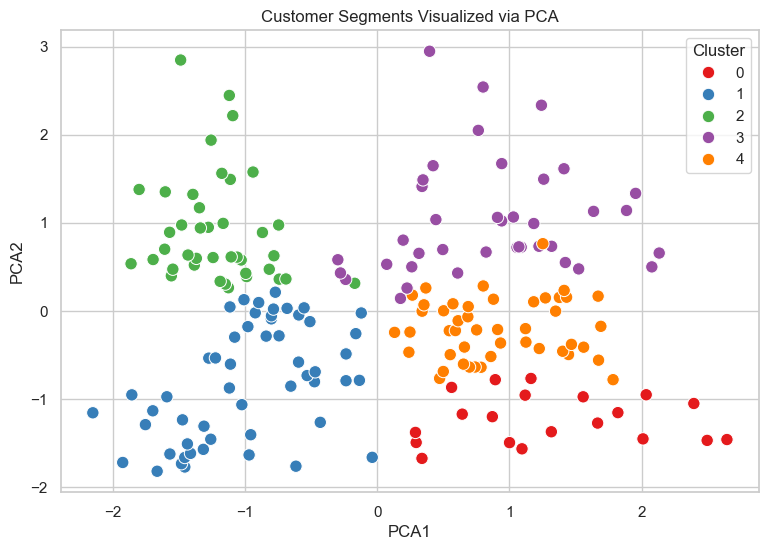

Explained variance ratio: [0.44266167 0.33308378]


In [21]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:,0]
df['PCA2'] = X_pca[:,1]

plt.figure(figsize=(9,6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='Set1', s=80)
plt.title("Customer Segments Visualized via PCA")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)

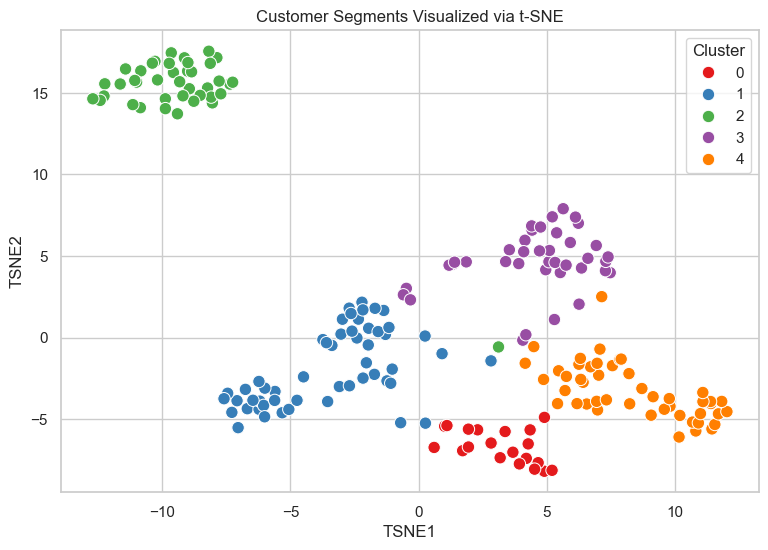

In [23]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

df['TSNE1'] = X_tsne[:,0]
df['TSNE2'] = X_tsne[:,1]

plt.figure(figsize=(9,6))
sns.scatterplot(x='TSNE1', y='TSNE2', hue='Cluster', data=df, palette='Set1', s=80)
plt.title("Customer Segments Visualized via t-SNE")
plt.show()